# Entropy-Regularised OT Resampling with the Sinkhorn Algorithm

This notebook showcases the **Differentiable Ensemble Transform (DET)** resampling scheme
and how to tune its regularisation parameter $\epsilon$ and Sinkhorn iteration budget
`max_iter` for the **bias–variance–speed** trade-off.

**Reference:** Corenflos, Thornton, Deligiannidis & Doucet,
*Differentiable Particle Filtering via Entropy-Regularized Optimal Transport*,
ICML 2021 (PMLR 139).

---

## Method at a Glance

Standard resampling (multinomial, systematic) is **not differentiable** w.r.t.
model parameters $\theta$. DET replaces it with an entropy-regularised OT step.

**Entropy-regularised OT problem** (Eq. 9):
$$\mathcal{W}_{2,\epsilon}^2(\alpha_N, \beta_N)
  = \min_{\mathbf{P}\in\mathcal{S}(\mathbf{a},\mathbf{b})}
    \sum_{i,j} p_{i,j}\!\left(c_{i,j}
    + \epsilon\log\frac{p_{i,j}}{a_i b_j}\right)$$
where $c_{i,j}=\tfrac{1}{2}\|X_i-X_j\|^2$ and $\epsilon>0$ is the regularisation strength.

**Sinkhorn iteration** (Algorithm 2) solves for dual potentials $(\mathbf{f}^*,\mathbf{g}^*)$:
$$f_i\leftarrow\tfrac{1}{2}\bigl(f_i+\mathcal{T}_\epsilon(\mathbf{b},\mathbf{g},\mathbf{C}_{i,:})\bigr),
  \qquad
  g_i\leftarrow\tfrac{1}{2}\bigl(g_i+\mathcal{T}_\epsilon(\mathbf{a},\mathbf{f},\mathbf{C}_{:,i})\bigr)$$
with the softmin operator
$\mathcal{T}_\epsilon(\mathbf{a},\mathbf{f},\mathbf{C}_{:,i})
  =-\epsilon\log\sum_k\exp\!\bigl(\log a_k+\epsilon^{-1}(f_k-c_{k,i})\bigr)$.

**Transport matrix** (Eq. 12) and **resampled particles** (Eq. 13):
$$p_{\epsilon,i,j}^{\text{OT}}=a_ib_j\exp\!\bigl(\epsilon^{-1}(f_i^*+g_j^*-c_{i,j})\bigr),
  \qquad
  \tilde X_t^i = N\sum_k p_{\epsilon,i,k}^{\text{OT}}X_t^k$$

In [1]:
import sys, time
sys.path.append("..")

import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
import matplotlib.pyplot as plt
import attr

# dpf modules
from dpf import SMC, State
from dpf.observation.linear import LinearObservationModel
from dpf.transition import RandomWalkModel
from dpf.proposal.bootstrap import BootstrapProposal
from dpf.resampling.criterion import NeffCriterion
from dpf.resampling.differentiable.regularised_ot_resample import RegularisedOTResampler
from dpf.resampling.differentiable.regularized_optimal_transport.plan import transport

tfd = tfp.distributions
DTYPE = tf.float64

# Reproducibility
np.random.seed(42); tf.random.set_seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1 — How $\epsilon$ Shapes the Transport Matrix

We create $N=20$ particles from a bimodal Gaussian mixture with
**non-uniform weights** (right cluster has 5× the weight).

- Small $\epsilon$: close to exact OT.
- Large $\epsilon$: not close to exact OT.

Create the toy particle set and fix the Sinkhorn hyperparameters
(`scaling=0.75`, convergence threshold $10^{-4}$) shared across the
$\epsilon$ sweep.

In [2]:
N, B = 20, 1  # 20 particles, single batch element
np.random.seed(7)

# --- Particles: bimodal mixture, sorted for clearer visualisation ---
x_np = np.sort(np.concatenate([np.random.normal(-2, 0.5, N//2),   # left cluster
                                np.random.normal( 2, 0.5, N//2)])) # right cluster
x = tf.constant(x_np.reshape(B, N, 1), dtype=DTYPE)

# --- Weights: right cluster has 5x the mass ---
raw_w = np.ones(N); raw_w[N//2:] = 5.0; raw_w /= raw_w.sum()
logw = tf.constant(np.log(raw_w).reshape(B, N), dtype=DTYPE)
w = tf.nn.softmax(logw, axis=-1).numpy()[0]

# --- Sinkhorn hyperparameters (fixed across the epsilon sweep) ---
scaling = tf.constant(0.75, dtype=DTYPE)   # epsilon-scaling factor
thresh  = tf.constant(1e-4, dtype=DTYPE)   # convergence threshold

# Eight epsilon values spanning two orders of magnitude
epsilons = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]

For each $\epsilon$ we call `transport()` — the low-level function that
centres/scales particles (Section 3.2), runs the Sinkhorn loop
(Algorithm 2), and recovers the transport matrix (Eq. 12).
Entry $\mathbf{T}[i,j]$ is how much of source particle $j$ flows
into target particle $i$.

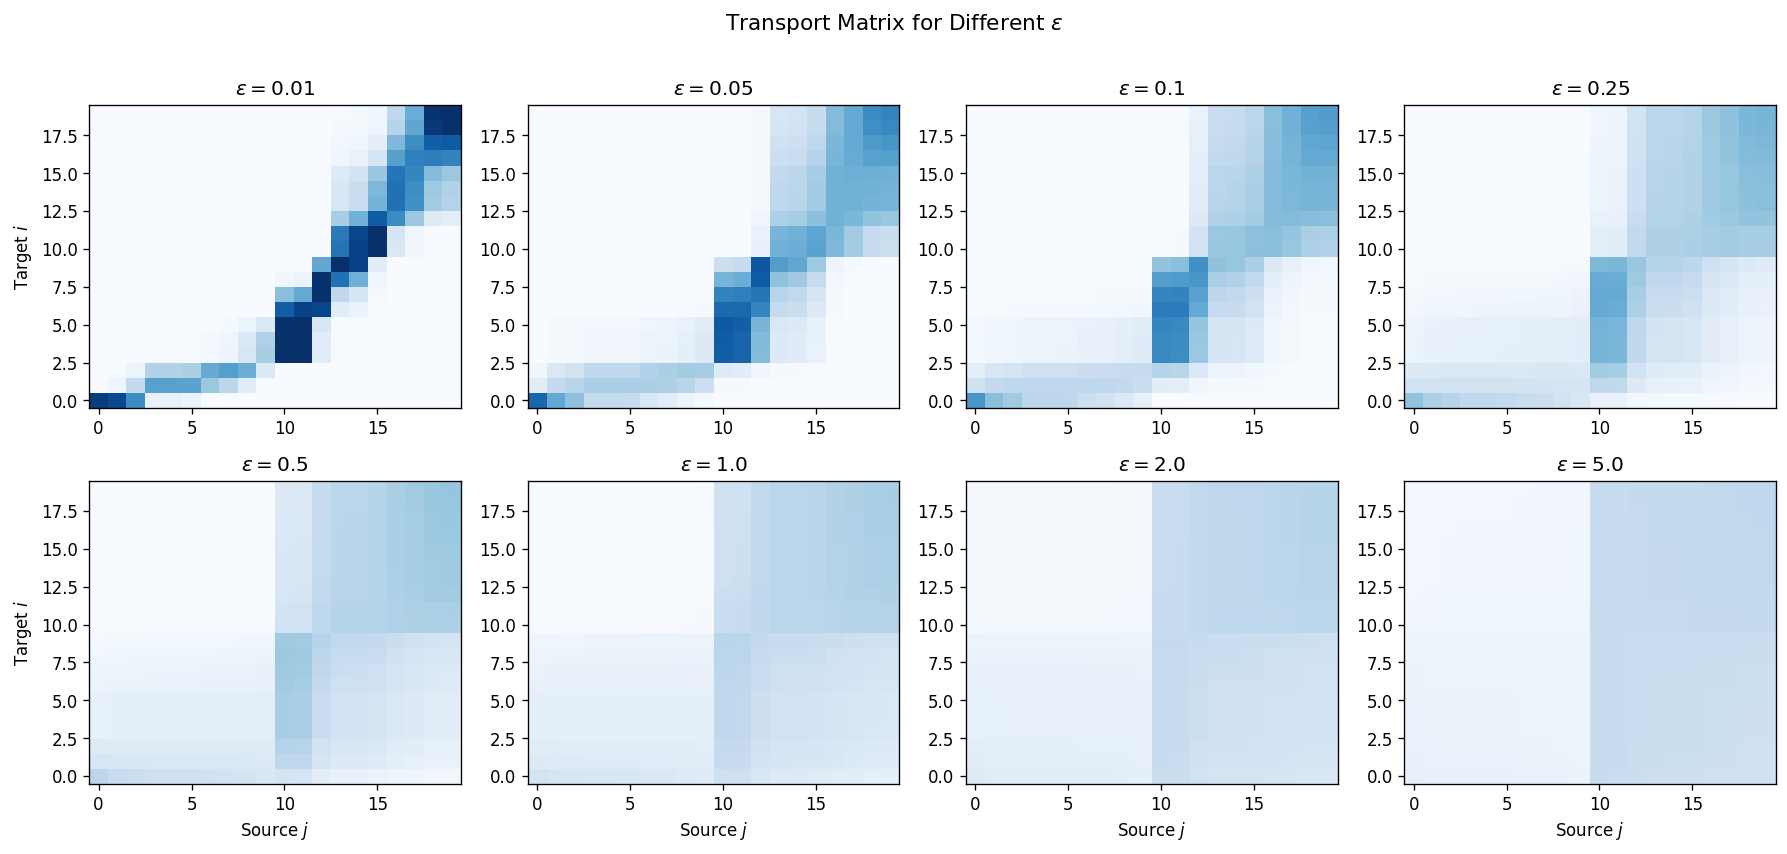

In [3]:
# Compute and plot the transport matrix T = N * P^OT_eps for each epsilon
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for idx, eps_val in enumerate(epsilons):
    # transport() runs: centre/scale -> Sinkhorn potentials -> recover P^OT_eps
    T_mat = transport(x, logw, tf.constant(eps_val, dtype=DTYPE),
                      scaling, thresh, tf.constant(500, tf.int32), N)
    ax = axes[idx // 4, idx % 4]
    ax.imshow(T_mat[0].numpy(), cmap='Blues', aspect='auto',
              origin='lower', vmin=0, vmax=0.35)
    ax.set_title(f'$\\epsilon = {eps_val}$')
    if idx % 4 == 0: ax.set_ylabel('Target $i$')
    if idx >= 4:     ax.set_xlabel('Source $j$')

fig.suptitle('Transport Matrix for Different $\\epsilon$', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 2 — Bias–Variance–Speed Trade-off on a Linear-Gaussian SSM

We run a particle filter with `RegularisedOTResampler` on the
1-D random-walk SSM:
$$x_t = x_{t-1}+w_t,\; w_t\sim\mathcal N(0,0.25),
  \qquad y_t = x_t+v_t,\; v_t\sim\mathcal N(0,0.25)$$

We sweep a grid of $(\epsilon,\,\texttt{max\_iter})$ and measure three
quantities directly from the OT-resampled particle filter:
- **Log-likelihood** $\hat\ell(\theta)$ — proxy for **bias**
  (higher = better fit; sensitive to over-smoothing from large $\epsilon$).
- **Mean ESS** — proxy for **variance**
  (higher = less weight degeneracy, more effective particles).
- **Wall time** — proxy for **speed**.

Generate synthetic data from the SSM and build the shared PF model
components (transition / observation distributions, initial particle cloud).

In [4]:
# ---------- Synthetic data ----------
# 1-D random-walk SSM: x_t = x_{t-1} + w_t,  y_t = x_t + v_t
T_steps, batch_size, n_particles = 80, 4, 100
sigma_x, sigma_y = 0.5, 0.5  # transition / observation noise std

np.random.seed(42)
# Generate true latent trajectory and noisy observations
true_states = np.cumsum(np.concatenate([[0], np.random.normal(0, sigma_x, T_steps-1)]))
obs_np = true_states[:, None] + np.random.normal(0, sigma_y, (T_steps, batch_size))
obs_tf = tf.constant(obs_np[:, :, None], dtype=DTYPE)  # shape [T, B, 1]

# ---------- PF model components ----------
F = tf.eye(1, dtype=DTYPE)   # state-transition matrix (identity for random walk)
H = tf.eye(1, dtype=DTYPE)   # observation matrix (identity for direct observation)
trans_noise = tfd.MultivariateNormalTriL(tf.zeros([1], dtype=DTYPE),
                                         tf.constant([[sigma_x]], dtype=DTYPE))
obs_noise   = tfd.MultivariateNormalTriL(tf.zeros([1], dtype=DTYPE),
                                         tf.constant([[sigma_y]], dtype=DTYPE))
trans_model = RandomWalkModel(F, trans_noise)

# ---------- Initial particle cloud ----------
# N particles drawn from N(0,1), with uniform weights 1/N
np.random.seed(0)
initial_state = State(
    particles=tf.constant(np.random.randn(batch_size, n_particles, 1), dtype=DTYPE),
    log_weights=tf.fill([batch_size, n_particles],
                        -tf.math.log(tf.cast(n_particles, DTYPE))))

`run_pf` runs a full bootstrap particle filter for $T$ steps using
`RegularisedOTResampler` and returns the log-likelihood, mean ESS,
and wall-clock time.

In [5]:
def run_pf(resampler):
    """Run a bootstrap PF with the given resampler.

    Returns
    -------
    log_lik : float
        Mean log-likelihood across batches.
    mean_ess : float
        Mean ESS averaged over all time steps and batches.
    elapsed : float
        Wall-clock time in seconds.
    """
    smc = SMC(observation_model=LinearObservationModel(H, obs_noise),
              transition_model=trans_model,
              proposal_model=BootstrapProposal(trans_model),
              resampling_criterion=NeffCriterion(threshold_ratio=0.5),
              resampling_method=resampler)
    ess_list = []
    state = initial_state
    t0 = time.time()
    for t in range(T_steps):
        state = smc.one_step(state, obs_tf[t])     # resample -> propagate -> reweight
        state = attr.evolve(state, t=t+1)
        ess_list.append(state.ess.numpy())          # [B]
    elapsed = time.time() - t0
    log_lik  = float(tf.reduce_mean(state.log_likelihoods).numpy())
    mean_ess = float(np.mean(ess_list))
    return log_lik, mean_ess, elapsed

Sweep over a grid of 7 $\epsilon$ values $\times$ 5 `max_iter` values
(= 35 PF runs). For each configuration we record
log-likelihood, mean ESS, and wall time.

In [6]:
# --- Grid of (epsilon, max_iter) configurations ---
eps_grid  = [0.05, 0.1, 0.25, 0.5, 0.75, 1.0, 2.0]
iter_grid = [10, 25, 50, 100, 200]

ll_grid   = np.zeros((len(eps_grid), len(iter_grid)))
time_grid = np.zeros_like(ll_grid)
ess_grid  = np.zeros_like(ll_grid)

for i, eps in enumerate(eps_grid):
    for j, mi in enumerate(iter_grid):
        log_lik, mean_ess, elapsed = run_pf(
            RegularisedOTResampler(epsilon=eps, scaling=0.75,
                                   max_iter=mi, convergence_threshold=1e-3))
        ll_grid[i, j]   = log_lik
        time_grid[i, j] = elapsed
        ess_grid[i, j]  = mean_ess

print(f"Grid sweep complete: {len(eps_grid)} x {len(iter_grid)} = "
      f"{len(eps_grid)*len(iter_grid)} runs")

Grid sweep complete: 7 x 5 = 35 runs


The three heatmaps below display the full trade-off surface.
Each cell is one $(\epsilon,\,\texttt{max\_iter})$ configuration;
the numerical value is printed inside for easy reading.

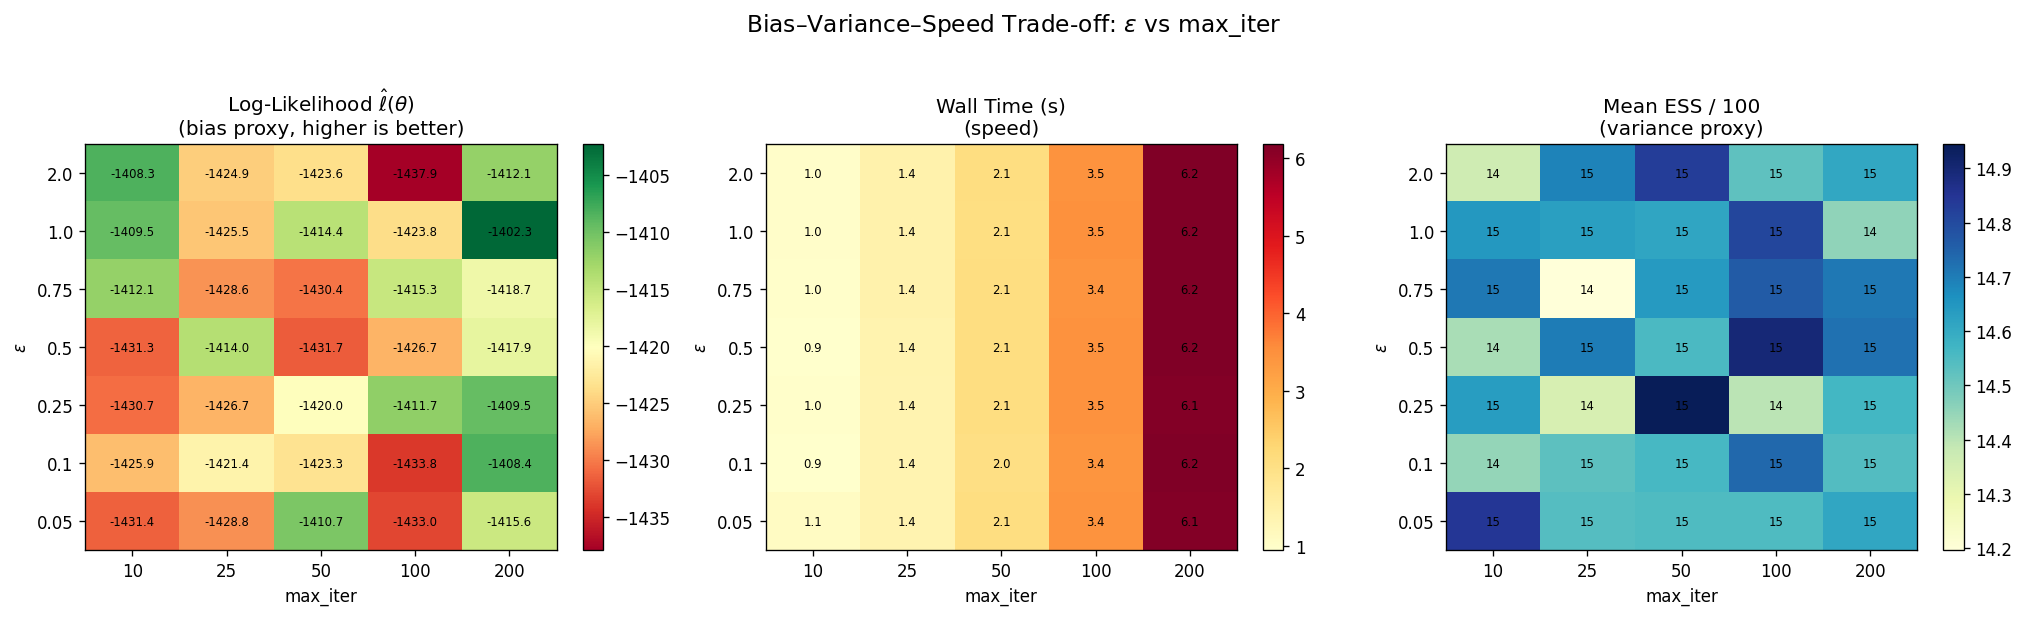

In [7]:
# --- Three side-by-side heatmaps: Log-Likelihood | Wall Time | Mean ESS ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
titles = ['Log-Likelihood $\\hat{\\ell}(\\theta)$\n(bias proxy, higher is better)',
          'Wall Time (s)\n(speed)',
          f'Mean ESS / {n_particles}\n(variance proxy)']
cmaps  = ['RdYlGn', 'YlOrRd', 'YlGnBu']
grids  = [ll_grid, time_grid, ess_grid]
fmts   = ['.1f', '.1f', '.0f']

for ax, data, cmap, title, fmt in zip(axes, grids, cmaps, titles, fmts):
    im = ax.imshow(data, cmap=cmap, aspect='auto', origin='lower')
    ax.set_xticks(range(len(iter_grid)))
    ax.set_xticklabels(iter_grid)
    ax.set_yticks(range(len(eps_grid)))
    ax.set_yticklabels([f'{e}' for e in eps_grid])
    ax.set_xlabel('max_iter');  ax.set_ylabel('$\\epsilon$')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    # Print numerical values inside each cell
    for r in range(len(eps_grid)):
        for c in range(len(iter_grid)):
            ax.text(c, r, f'{data[r,c]:{fmt}}', ha='center', va='center', fontsize=7)

fig.suptitle('Bias\u2013Variance\u2013Speed Trade-off: $\\epsilon$ vs max_iter',
             fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 3 — Gradient-Based Training with OT Resampling

The key advantage of DET: the transport matrix $\mathbf{P}_\epsilon^{\text{OT}}$
is differentiable w.r.t. both particles and weights, so gradients of the
PF log-likelihood $\hat\ell(\theta)$ flow back through resampling to any
upstream model parameter $\theta$.

Below we demonstrate this end-to-end: we start the observation noise
parameter at the **wrong value** $\sigma_y = 1.0$ (true $= 0.5$) and use
Adam to minimise the negative log-likelihood. 

`build_and_run` assembles an SMC with one **trainable** parameter
$\theta = \log\sigma_y$ and runs it on the observations.
The resampler and resampling criterion are passed in so the same
helper can be reused with any resampling method.

In [8]:
def build_and_run(theta_var, resampler, criterion):
    """Build SMC with one trainable observation-noise parameter and run it.

    Parameters
    ----------
    theta_var : tf.Variable, shape [1, 1]
        Log observation noise:  sigma_y = exp(theta_var).
    resampler : ResamplerBase
        Resampling method (e.g. RegularisedOTResampler).
    criterion : ResamplingCriterionBase
        When to resample (e.g. NeffCriterion).

    Returns
    -------
    State  — final particle-filter state (carries .log_likelihoods).
    """
    # Trainable observation noise
    obs_n = tfd.MultivariateNormalTriL(
        loc=tf.zeros([1], dtype=DTYPE),
        scale_tril=tf.exp(theta_var))
    # Fixed transition noise
    trans_n = tfd.MultivariateNormalTriL(
        loc=tf.zeros([1], dtype=DTYPE),
        scale_tril=tf.constant([[0.5]], dtype=DTYPE))
    tm = RandomWalkModel(F, trans_n)
    smc = SMC(
        observation_model=LinearObservationModel(H, obs_n),
        transition_model=tm,
        proposal_model=BootstrapProposal(tm),
        resampling_criterion=criterion,
        resampling_method=resampler)
    return smc(initial_state, obs_tf)

We run 70 Adam steps starting from $\theta = 0$ ($\sigma_y = 1$).
At each step `tf.GradientTape` differentiates through the full PF
— including the OT resampling step — and the optimiser updates $\theta$.

In [9]:
# --- Trainable parameter: log(sigma_y), initialised at the wrong value ---
theta = tf.Variable(tf.constant([[0.0]], dtype=DTYPE))  # sigma_y = exp(0) = 1.0
optimizer = tf.optimizers.Adam(learning_rate=0.05)

# OT resampler with the recommended defaults
resampler = RegularisedOTResampler(
    epsilon=0.5, scaling=0.75, max_iter=100, convergence_threshold=1e-3)
criterion = NeffCriterion(threshold_ratio=0.5)

losses, scales = [], []
for i in range(70):
    with tf.GradientTape() as tape:
        final = build_and_run(theta, resampler, criterion)
        loss = -tf.reduce_mean(final.log_likelihoods)   # negative log-likelihood
    g = tape.gradient(loss, [theta])
    if g[0] is not None:
        optimizer.apply_gradients(zip(g, [theta]))
    losses.append(loss.numpy())
    scales.append(tf.exp(theta).numpy().item())
    if (i + 1) % 10 == 0:
        print(f'Iter {i+1:2d} | loss={loss.numpy():.1f} '
              f'| sigma_y={scales[-1]:.4f} (true=0.5)')

Iter 10 | loss=498.2 | sigma_y=1.6167 (true=0.5)
Iter 20 | loss=621.4 | sigma_y=2.3777 (true=0.5)
Iter 30 | loss=828.1 | sigma_y=2.9247 (true=0.5)
Iter 40 | loss=821.4 | sigma_y=2.9517 (true=0.5)
Iter 50 | loss=756.8 | sigma_y=2.7264 (true=0.5)
Iter 60 | loss=725.6 | sigma_y=2.5894 (true=0.5)
Iter 70 | loss=694.6 | sigma_y=2.5970 (true=0.5)


Plot the loss curve and the recovered $\sigma_y$ over the 70 iterations.

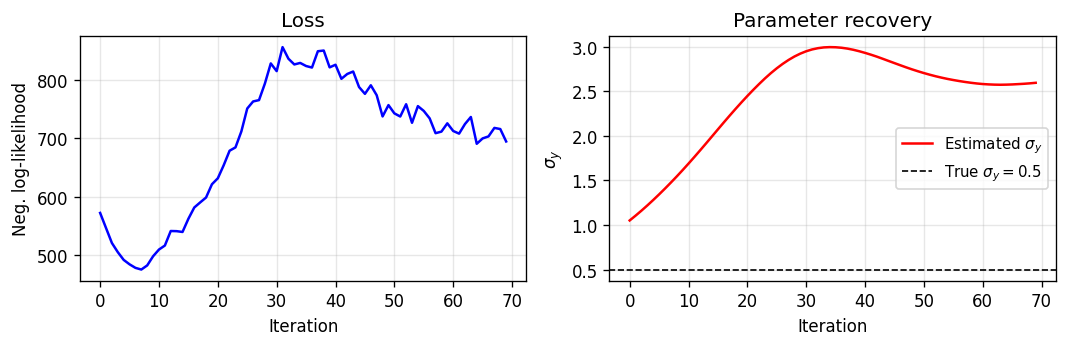

Final recovered sigma_y = 2.5970  (true = 0.5)


In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3))

# Left: loss curve
a1.plot(losses, 'b-')
a1.set(xlabel='Iteration', ylabel='Neg. log-likelihood', title='Loss')
a1.grid(alpha=0.3)

# Right: recovered sigma_y
a2.plot(scales, 'r-', label='Estimated $\\sigma_y$')
a2.axhline(0.5, color='k', ls='--', lw=1, label='True $\\sigma_y = 0.5$')
a2.set(xlabel='Iteration', ylabel='$\\sigma_y$', title='Parameter recovery')
a2.legend(fontsize=9)
a2.grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Final recovered sigma_y = {scales[-1]:.4f}  (true = 0.5)')